In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append(f"./../")

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np

In [3]:
edge_counts = []
bipartite_counts = defaultdict(int)
diameters = []
clique_numbers = []

with open('../data/graphs/negative_graphs.g6', 'r') as file:
    for line in file:
        try:
            G = nx.from_graph6_bytes(line.strip().encode('utf-8'))
            
            # Number of edges
            edge_counts.append(G.number_of_edges())
            
            # Bipartiteness
            bipartite_counts[nx.is_bipartite(G)] += 1
            
            # Diameter (only for connected graphs)
            if nx.is_connected(G):
                diameters.append(nx.diameter(G))
            
            # Clique number (size of the largest clique)
            clique_number = max(len(c) for c in nx.find_cliques(G))
            clique_numbers.append(clique_number)
        
        except nx.NetworkXError as e:
            print(f"Error processing graph: {e}")

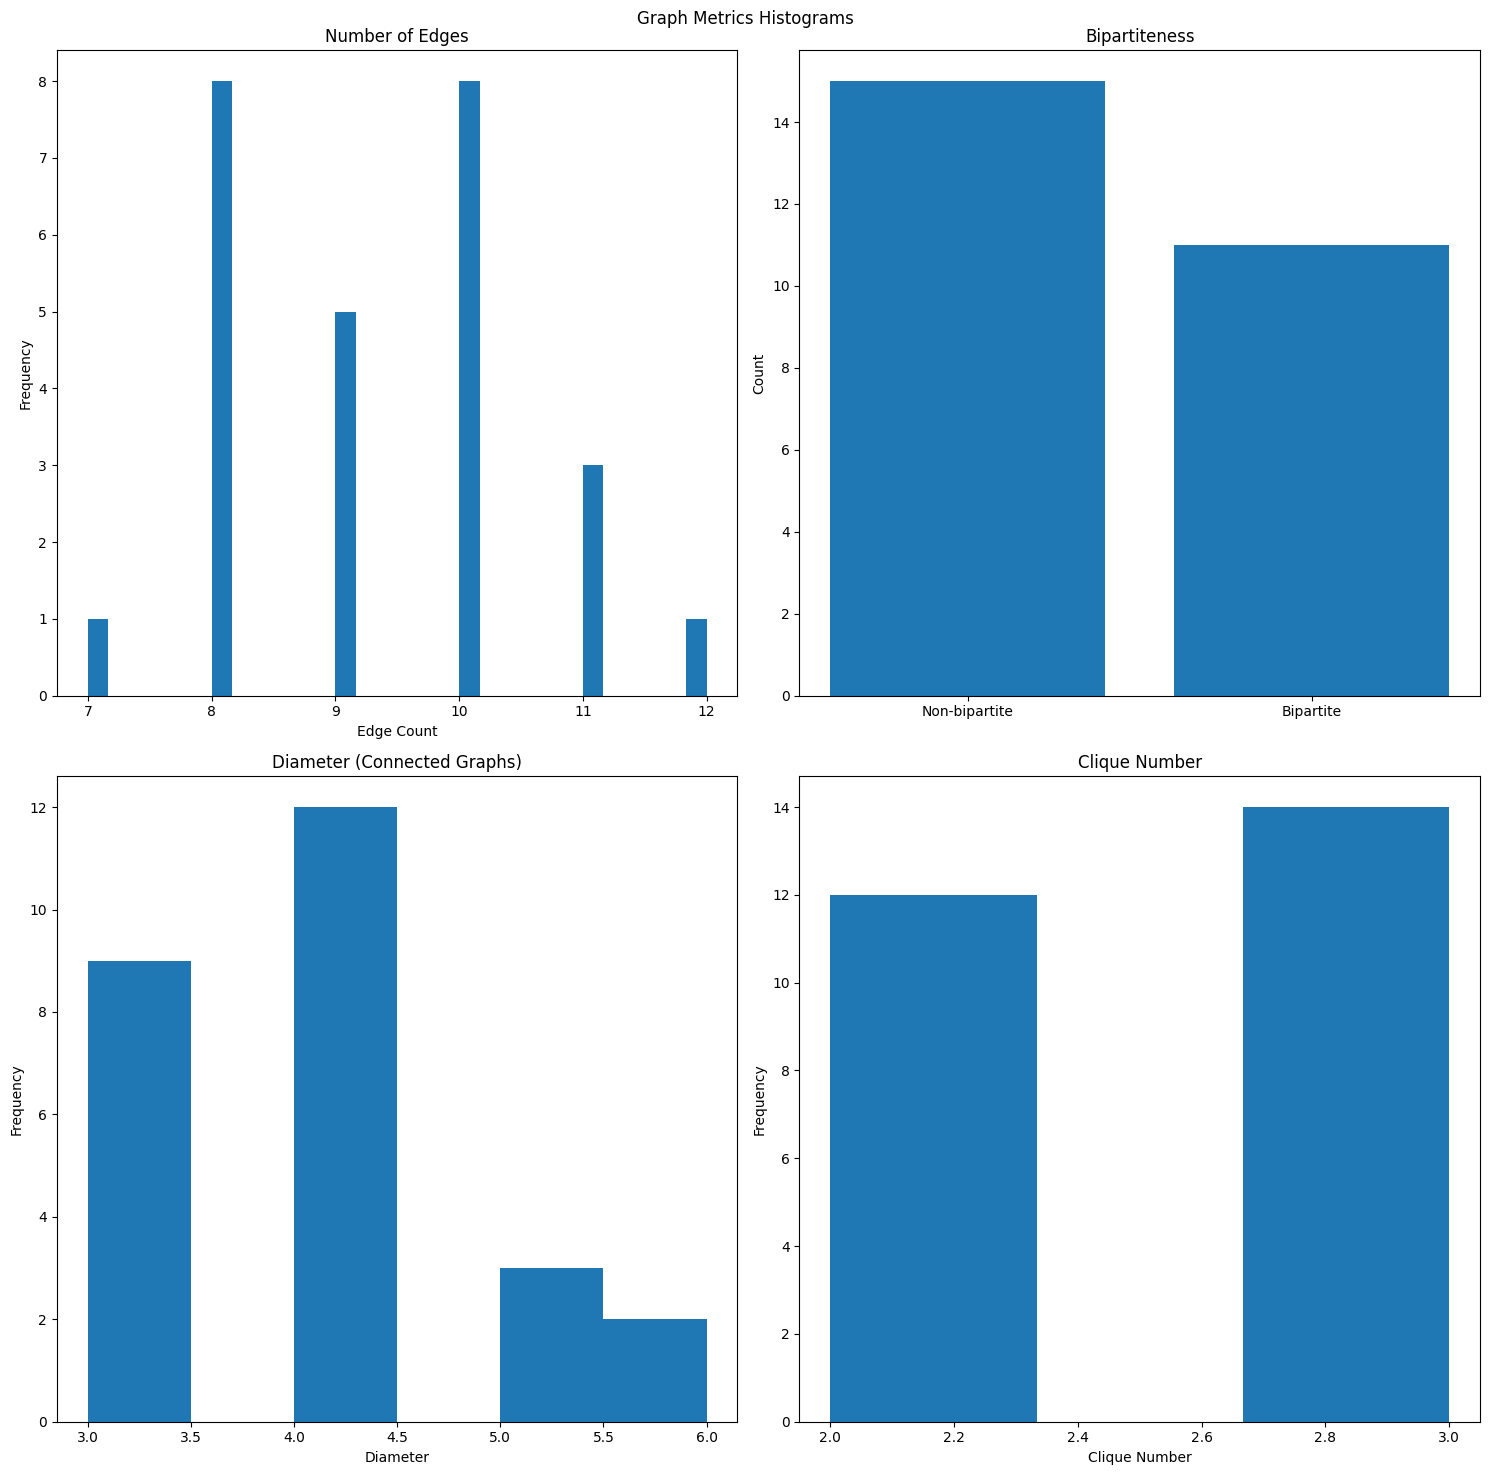

In [4]:
fig, axs = plt.subplots(2, 2, figsize=(15, 15))
fig.suptitle('Graph Metrics Histograms')

axs[0, 0].hist(edge_counts, bins=30)
axs[0, 0].set_title('Number of Edges')
axs[0, 0].set_xlabel('Edge Count')
axs[0, 0].set_ylabel('Frequency')

axs[0, 1].bar(bipartite_counts.keys(), bipartite_counts.values())
axs[0, 1].set_title('Bipartiteness')
axs[0, 1].set_xticks([0, 1])
axs[0, 1].set_xticklabels(['Non-bipartite', 'Bipartite'])
axs[0, 1].set_ylabel('Count')

axs[1, 0].hist(diameters, bins=max(diameters))
axs[1, 0].set_title('Diameter (Connected Graphs)')
axs[1, 0].set_xlabel('Diameter')
axs[1, 0].set_ylabel('Frequency')

axs[1, 1].hist(clique_numbers, bins=max(clique_numbers))
axs[1, 1].set_title('Clique Number')
axs[1, 1].set_xlabel('Clique Number')
axs[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [5]:
# Print summary statistics
print(f"Total graphs processed: {len(edge_counts)}")
print(f"Edge count - Min: {min(edge_counts)}, Max: {max(edge_counts)}, Mean: {np.mean(edge_counts):.2f}")
print(f"Bipartite graphs: {bipartite_counts[True]}, Non-bipartite graphs: {bipartite_counts[False]}")
print(f"Diameter - Min: {min(diameters)}, Max: {max(diameters)}, Mean: {np.mean(diameters):.2f}")
print(f"Clique number - Min: {min(clique_numbers)}, Max: {max(clique_numbers)}, Mean: {np.mean(clique_numbers):.2f}")

Total graphs processed: 26
Edge count - Min: 7, Max: 12, Mean: 9.27
Bipartite graphs: 11, Non-bipartite graphs: 15
Diameter - Min: 3, Max: 6, Mean: 3.92
Clique number - Min: 2, Max: 3, Mean: 2.54
